In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords

from sklearn.svm import SVC
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Загрузка данных
df = pd.read_csv('stats_for_ml.csv')

In [3]:
df.head()

,tokenize_text
0,agi стучаться дверь человечество думать стать ...
1,asr cpu выбрать бэкенд настроить triton потеря...
2,claude code требовать паспорт codex уметь рабо...
3,microsoft заверить windows 11 прекрасно обходи...
4,opus 47 плохой релиз anthropic bothub экосисте...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   tokenize_text  30 non-null     object
dtypes: object(1)
memory usage: 372.0+ bytes


## Векторизация текста

In [5]:
russian_stopwords = stopwords.words("russian") 
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','свой','своём','всем','всё','её','оба','ещё','должный']) 

In [6]:
# TF-IDF векторизация
vectorizer = TfidfVectorizer(
    max_features=5000,  
    min_df=2,           
    max_df=0.95,        
    ngram_range=(1, 3),  
    stop_words=russian_stopwords      
)

tfidf_matrix = vectorizer.fit_transform(df['tokenize_text'])
print(f"Размер TF-IDF матрицы: {tfidf_matrix.shape}")
print(f"Количество признаков: {len(vectorizer.get_feature_names_out())}")

Размер TF-IDF матрицы: (30, 253)
Количество признаков: 253


## Определение оптимального количества кластеров

In [7]:
from sklearn.decomposition import NMF

In [8]:
# создание модели NMF
nmf_model = NMF(n_components=5, random_state=0)
nmf_model.fit(tfidf_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: ai, экосистема ai, экосистема, bothub экосистема ai, экосистема ai инструмент, bothub экосистема, bothub, ai инструмент, инструмент, anthropic bothub экосистема
Topic 1: разработчик, отсутствовать, система, техника, сообщество, требовать паспорт, требовать, уметь работать, уметь работать любой, система инструмент разработчик
Topic 2: автоматизация, платформа автоматизация бизнеспроцесс, платформа автоматизация, плохо, плохо платформа автоматизация, вайбкодинг плохо, вайбкодинг, автоматизация бизнеспроцесс, бизнеспроцесс, вайбкодинг плохо платформа
Topic 3: будущее, точность, точность создавать решение, создавать решение будущее, точность создавать, сегодня, решение, решение будущее, решение будущее сегодня, создавать решение
Topic 4: открывать набор, набор летний итшкола, набор летний, открывать, набор, открывать набор летний, итшкола, летний итшкола 2026, летний итшкола, крок открывать


In [9]:
nmf_model = NMF(n_components=7, random_state=0)
nmf_model.fit(tfidf_matrix)

for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: ai, экосистема ai, экосистема, bothub экосистема ai, экосистема ai инструмент, bothub экосистема, bothub, ai инструмент, инструмент, anthropic bothub экосистема
Topic 1: разработчик, отсутствовать, система, техника, сообщество, требовать паспорт, требовать, уметь работать, уметь работать любой, система инструмент разработчик
Topic 2: автоматизация, платформа автоматизация бизнеспроцесс, платформа автоматизация, плохо, плохо платформа автоматизация, вайбкодинг плохо, вайбкодинг, автоматизация бизнеспроцесс, бизнеспроцесс, вайбкодинг плохо платформа
Topic 3: будущее, точность, точность создавать решение, создавать решение будущее, точность создавать, сегодня, решение, решение будущее, решение будущее сегодня, создавать решение
Topic 4: открывать набор, набор летний итшкола, набор летний, открывать, набор, открывать набор летний, итшкола, летний итшкола 2026, летний итшкола, крок открывать
Topic 5: человечество думать, человечество думать стать, хороший друг, хороший друг самый, 

In [10]:
X_topics_nmf = nmf_model.fit_transform(tfidf_matrix)

df['topic_nmf'] = np.argmax(X_topics_nmf, axis=1)

In [11]:
df.head(10)

,tokenize_text,topic_nmf
0,agi стучаться дверь человечество думать стать ...,5
1,asr cpu выбрать бэкенд настроить triton потеря...,3
2,claude code требовать паспорт codex уметь рабо...,1
3,microsoft заверить windows 11 прекрасно обходи...,0
4,opus 47 плохой релиз anthropic bothub экосисте...,0
5,вайбкодинг плохо платформа автоматизация бизне...,2
6,крок открывать набор летний итшкола 2026 16544...,4
7,наплыть музыка сгенерировать ия менять подход ...,6
8,сэм альтман критиковать кибермодель mythos ant...,0
9,топ 12 сервис нейросеть генерация изображение ...,0


In [12]:
df['topic_nmf'].value_counts()

topic_nmf
0    9
1    8
6    4
2    3
5    2
3    2
4    2
Name: count, dtype: int64

Расчет метрик для разных K...
Обработка K=2...


  File "C:\Users\rafael\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\rafael\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rafael\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rafael\anaconda3\Lib\subproc

  K=2: WCSS=23.90, Silhouette=0.0877
Обработка K=3...
  K=3: WCSS=22.22, Silhouette=0.1149
Обработка K=4...
  K=4: WCSS=20.16, Silhouette=0.1559
Обработка K=5...
  K=5: WCSS=18.39, Silhouette=0.2119
Обработка K=6...
  K=6: WCSS=16.81, Silhouette=0.3342
Обработка K=7...
  K=7: WCSS=15.03, Silhouette=0.2641
Обработка K=8...
  K=8: WCSS=13.10, Silhouette=0.4855
Обработка K=9...
  K=9: WCSS=11.27, Silhouette=0.5410
Обработка K=10...
  K=10: WCSS=9.33, Silhouette=0.6102


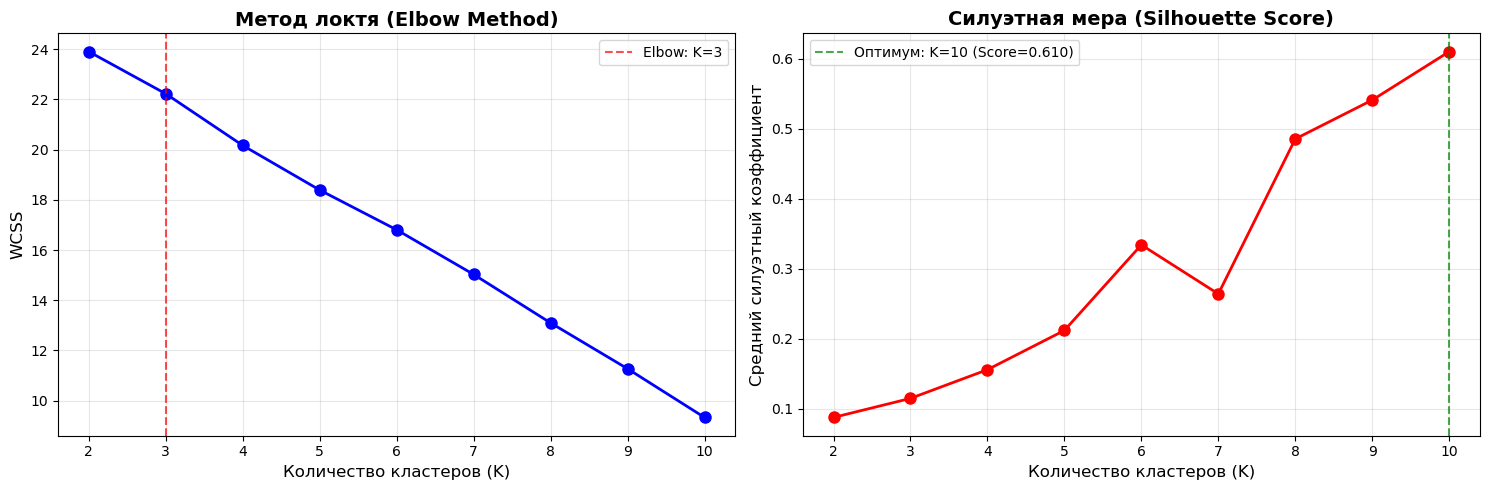


ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: 10
Лучший силуэтный коэффициент: 0.6102

Интерпретация:
✓ Хорошая кластеризация


In [13]:
# Расчет WCSS и силуэтных оценок
wcss = []
silhouette_scores = []

# Для силуэта нужно минимум 2 кластера
K_range = range(2, 11)  # От 2 до 10 кластеров

print("Расчет метрик для разных K...")
for k in K_range:
    print(f"Обработка K={k}...")
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(tfidf_matrix)
    
    # WCSS
    wcss.append(kmeans.inertia_)
    
    # Силуэтная мера (на выборке, так как полная матрица может быть большой)
    if tfidf_matrix.shape[0] > 5000:
        # Для больших данных берем выборку
        sample_size = min(5000, tfidf_matrix.shape[0])
        indices = np.random.choice(tfidf_matrix.shape[0], sample_size, replace=False)
        silhouette_avg = silhouette_score(tfidf_matrix[indices], cluster_labels[indices])
    else:
        silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
    
    silhouette_scores.append(silhouette_avg)
    print(f"  K={k}: WCSS={kmeans.inertia_:.2f}, Silhouette={silhouette_avg:.4f}")

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Метод локтя
ax1.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Метод локтя (Elbow Method)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Количество кластеров (K)', fontsize=12)
ax1.set_ylabel('WCSS', fontsize=12)
ax1.grid(True, alpha=0.3)

# Находим точку перегиба (elbow)
if len(wcss) > 2:
    deltas = np.diff(wcss)
    delta2_deltas = np.diff(deltas)
    elbow_k = K_range[np.argmin(delta2_deltas) + 1] if len(delta2_deltas) > 0 else K_range[np.argmin(deltas)]
    ax1.axvline(x=elbow_k, color='red', linestyle='--', alpha=0.7, label=f'Elbow: K={elbow_k}')
    ax1.legend()

# Силуэтная мера
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_title('Силуэтная мера (Silhouette Score)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Количество кластеров (K)', fontsize=12)
ax2.set_ylabel('Средний силуэтный коэффициент', fontsize=12)
ax2.grid(True, alpha=0.3)

best_k_silhouette = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
ax2.axvline(x=best_k_silhouette, color='green', linestyle='--', alpha=0.7, 
            label=f'Оптимум: K={best_k_silhouette} (Score={best_score:.3f})')
ax2.legend()

plt.tight_layout()
plt.show()

# Выбор оптимального K
optimal_k = best_k_silhouette  # Используем optimal_k = best_k_silhouette
print(f"\n{'='*50}")
print(f"ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: {optimal_k}")
print(f"{'='*50}")
print(f"Лучший силуэтный коэффициент: {best_score:.4f}")
print(f"\nИнтерпретация:")
if best_score > 0.7:
    print("✓ Отличная кластеризация")
elif best_score > 0.5:
    print("✓ Хорошая кластеризация")
elif best_score > 0.25:
    print("⚠ Слабая кластеризация")
else:
    print("✗ Случайная кластеризация")

In [14]:
n_topics = 7
nmf_transformed = nmf_model.transform(tfidf_matrix)

print("="*50)
print("ПРОВЕРКА КЛАСТЕРИЗАЦИИ: ТОП-ПРИМЕРЫ ТЕКСТОВ ПО ТЕМАМ")
print("="*50)

for topic_idx in range(n_topics):
    topic_scores = nmf_transformed[:, topic_idx]
    
    top_docs_idx = np.argsort(topic_scores)[-3:][::-1]
    
    print(f"ТЕМА №{topic_idx}")
    
    for rank, doc_idx in enumerate(top_docs_idx, 1):
        full_text = df.iloc[doc_idx]['tokenize_text']
        preview_text = (full_text[:100] + '...') if len(full_text) > 100 else full_text
        
        score = topic_scores[doc_idx]
        
        print(f"  {rank}. Текст: {preview_text}")
        print(f"     Уверенность алгоритма: {score:.4f}")
    print("-" * 30)

ПРОВЕРКА КЛАСТЕРИЗАЦИИ: ТОП-ПРИМЕРЫ ТЕКСТОВ ПО ТЕМАМ
ТЕМА №0
  1. Текст: opus 47 плохой релиз anthropic bothub экосистема ai инструмент
     Уверенность алгоритма: 0.4652
  2. Текст: opus 47 плохой релиз anthropic bothub экосистема ai инструмент
     Уверенность алгоритма: 0.4652
  3. Текст: сэм альтман критиковать кибермодель mythos anthropic bothub экосистема ai инструмент
     Уверенность алгоритма: 0.4521
------------------------------
ТЕМА №1
  1. Текст: claude code требовать паспорт codex уметь работать любой приложение корпоративный система инструмент...
     Уверенность алгоритма: 0.5962
  2. Текст: claude code требовать паспорт codex уметь работать любой приложение корпоративный система инструмент...
     Уверенность алгоритма: 0.5962
  3. Текст: топ техника атака вебприложение 2025 разработчик защищаться нетривиальный уязвимость отсутствовать
     Уверенность алгоритма: 0.2925
------------------------------
ТЕМА №2
  1. Текст: вайбкодинг плохо платформа автоматизация бизнеспр

## Классификация

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['tokenize_text'], df['topic_nmf'], 
                                                      test_size=0.3, 
                                                      random_state=0)

In [16]:
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [17]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [18]:
model_lr = LogisticRegression()
model_lr.fit(X_train_tfidf, y_train)

LogisticRegression()

In [19]:
y_pred = model_lr.predict(X_test_tfidf)

In [20]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.40      1.00      0.57         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1
           3       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1

    accuracy                           0.67         9
   macro avg       0.40      0.50      0.43         9
weighted avg       0.53      0.67      0.57         9



In [21]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [22]:
y_pred = model_rf.predict(X_test_tfidf)

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1
           3       0.33      1.00      0.50         1
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1

    accuracy                           0.78         9
   macro avg       0.56      0.67      0.58         9
weighted avg       0.70      0.78      0.72         9



In [24]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_tfidf, y_train)

KNeighborsClassifier()

In [25]:
y_pred = model_knn.predict(X_test_tfidf)

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.29      1.00      0.44         2
           1       0.00      0.00      0.00         3
           2       1.00      1.00      1.00         1
           3       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         1

    accuracy                           0.44         9
   macro avg       0.38      0.50      0.41         9
weighted avg       0.29      0.44      0.32         9



## Сохранение моделей

In [27]:
import pickle

with open('model_rf_stats.pkl', 'wb') as f:
    pickle.dump(model_rf, f)

In [28]:
with open('vectorizer_stats.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

In [29]:
df.to_csv('data_movies2_classification_regression.csv')

In [30]:
df.head()

,tokenize_text,topic_nmf
0,agi стучаться дверь человечество думать стать ...,5
1,asr cpu выбрать бэкенд настроить triton потеря...,3
2,claude code требовать паспорт codex уметь рабо...,1
3,microsoft заверить windows 11 прекрасно обходи...,0
4,opus 47 плохой релиз anthropic bothub экосисте...,0


## Проверка модели

In [31]:
import pickle
import joblib
import pandas as pd
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pymorphy3
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
with open('model_rf.pkl', 'rb') as file:
    model = pickle.load(file)

with open('vectorizer.pkl', 'rb') as file:
    vectorizer = pickle.load(file)

In [33]:
def fun_punctuation_text(text):
    text = text.lower()
    text = ''.join([ch for ch in text if ch not in string.punctuation])
    text = ''.join([i if not i.isdigit() else '' for i in text])
    text = ''.join([i if i.isalpha() else ' ' for i in text])
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    text = re.sub('[a-z]', '', text, flags=re.I)
    st = '❯\xa0'
    text = ''.join([ch if ch not in st else ' ' for ch in text])
    return text

In [34]:
def fun_lemmatizing_text(text):
    tokens = word_tokenize(text)
    res = list()
    for word in tokens:
        p = pymorphy3.MorphAnalyzer(lang='ru').parse(word)[0]
        res.append(p.normal_form)  
    text = " ".join(res)
    return text

In [35]:
def fun_tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = " ".join(tokens)
    return text

In [36]:
t1 = "То самое облако"

In [37]:
t2 = "Корпоративные системы и инструменты разработчика"

In [38]:
t3 = "Bothub — экосистема AI инструментов"

In [39]:
t4 = "Инфостарт — сообщество и сервисы для 1С-разработки"

In [40]:
t5 = "Корпоративные системы и инструменты разработчика"

In [41]:
def predict_topic(text):
    text = fun_punctuation_text(text)
    text = fun_lemmatizing_text(text)
    text = fun_tokenize(text)
    text_vectorized = vectorizer.transform([text])
    prediction = model.predict(text_vectorized)
    probabilities = model.predict_proba(text_vectorized)
    return prediction, probabilities

In [42]:
prediction, probabilities = predict_topic(t1)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 0
Вероятности: [[0.99 0.   0.   0.01 0.   0.   0.  ]]


In [43]:
prediction, probabilities = predict_topic(t2)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 0
Вероятности: [[0.98 0.   0.   0.02 0.   0.   0.  ]]


In [44]:
prediction, probabilities = predict_topic(t3)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 0
Вероятности: [[0.99 0.   0.   0.01 0.   0.   0.  ]]


In [45]:
prediction, probabilities = predict_topic(t4)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 0
Вероятности: [[0.99 0.   0.   0.01 0.   0.   0.  ]]


In [46]:
prediction, probabilities = predict_topic(t5)
print(f"Класс: {prediction[0]}")
print(f"Вероятности: {probabilities}")

Класс: 0
Вероятности: [[0.98 0.   0.   0.02 0.   0.   0.  ]]


Topic 0 bothub экосистема ai..." — это разработка каких либо искусственных экосистем.

Topic 1 уметь работать сообщество разработчик..." — Разработка сообщественных проектов  или устройство на работу для создания групповых проектов.

Topic 2 вайбкодинг плохо бизнеспроцесс автоматизация ..." —  Улучшение каких либо процессов.

Topic 3 точность создавать будущее ..." — это статья о том как будет возможно с точностью создаваться в будещем.

Topic 4 летний итшкола 2026 итшкола открывать набор ..." — статья об открытие каких нибудь школ программирования.

Topic 5 стучаться дверь человечество хороший друг самый человечество думать..." — статья о том как человество задумывается, как быть хорошим человеком.

Topic 6 платформа обработка стриминговый сгенерировать ..." — генерация каких либо стримлинг процессов.

Вывод: 
    Провели кластеризацию  и классификацию по данным статей , для просмотра, как модель будет относить к определенным группам